<a href="https://colab.research.google.com/github/dreamcheap2000/Product/blob/main/Product_A_Strategic_Media_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>>> 階段 1: 正在執行深度審計 (15,000 次擬合)...
迭代 0: RMSE = 26945.50
迭代 3000: RMSE = 524.14
迭代 6000: RMSE = 50.98
迭代 9000: RMSE = 4.65
迭代 12000: RMSE = 0.42

>>> 階段 2: 正在優化預算分配 (25,000 次策略搜尋)...

PRODUCT A: 智慧媒體優化最終報告 (穩定收斂版)
       market  cost  gamma  Optimized_Budget  Change_%
0   Vancouver  1500   1200            659.15     -56.1
1      Barrie   400    550            764.02      91.0
2  St. John's   300    420            590.19      96.7
3  Chicoutimi   150    240            336.64     124.4
---------------------------------------------------------------------------
系統評估 (原始分配總觸及): 202,000 人
系統評估 (優化分配總觸及): 248,843 人
策略性效率提升 (ROI Gain): 23.19%


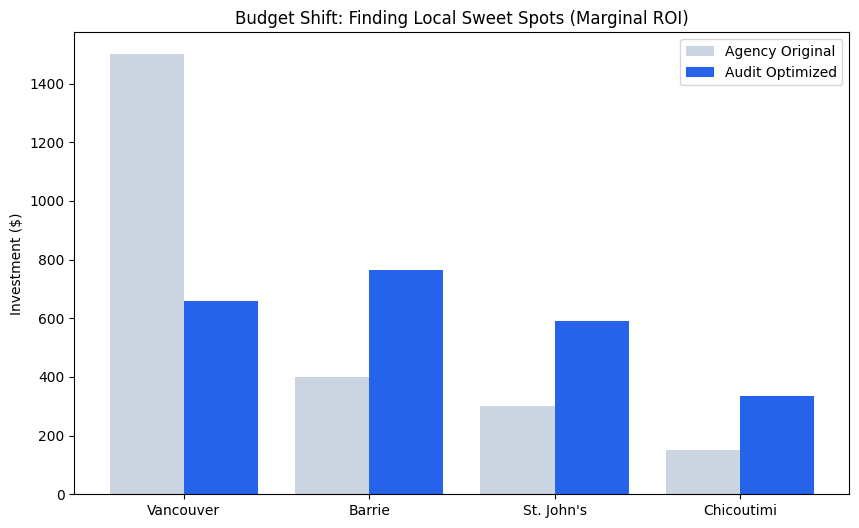

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 固定隨機種子以確保結果穩定可重複
np.random.seed(42)

class ProductAStrategicEngine:
    def __init__(self, market_data, demographic_weights):
        """
        :param market_data: DataFrame, 包含 'market', 'pop0', 'growth_rate', 'cost', 'v_actual', 'gamma'
        :param demographic_weights: 矩陣 (Cities x Groups), 城市內各族群比例 (w_ig)
        """
        self.df = market_data.copy()
        self.W = np.array(demographic_weights)
        num_cities, num_groups = self.W.shape

        # --- 1. 待學習參數 (Learnable Parameters) ---
        # theta_Ag: 每個目標群體的內在親和力 (如: [目標, 青少年, 成人])
        self.theta_Ag = np.array([0.2, 0.1, 0.05])
        self.theta_s = np.full(num_cities, 0.5)
        self.theta_k = np.ones(num_cities)

        # --- 2. 區域化飽和參數 (Hill Function) ---
        self.gamma = self.df['gamma'].values # 每個城市專屬的甜蜜點 (Market Capacity)
        self.n = 2 # S 曲線形狀因子

        # 學習率設定
        self.lr_audit = 1e-12
        self.history = []

    def hill_response(self, B, gamma_vals):
        """計算投資飽和響應: f(B) = B^n / (B^n + gamma^n)"""
        B_safe = np.clip(B, 1e-5, None)
        return (B_safe**self.n) / (B_safe**self.n + gamma_vals**self.n)

    def marginal_response(self, B, gamma_vals):
        """計算邊際收益 (Hill Function 的導數): dR/dB"""
        # 公式: (n * B^(n-1) * gamma^n) / (B^n + gamma^n)^2
        B_safe = np.clip(B, 1e-5, None)
        numerator = self.n * (B_safe**(self.n - 1)) * (gamma_vals**self.n)
        denominator = (B_safe**self.n + gamma_vals**self.n)**2
        return numerator / denominator

    def calculate_facts(self, t):
        """計算不隨優化改變的動態事實"""
        pop_t = self.df['pop0'].values * (1 + self.df['growth_rate'].values)**t
        cable_t = 0.95 / (1 + np.exp(-0.3 * (t - 10)))
        return pop_t, cable_t

    def audit_step(self, t):
        """階段 1: 審計 - 擬合數據真相"""
        pop_t, cable_t = self.calculate_facts(t)
        v_actual = self.df['v_actual'].values
        B = self.df['cost'].values

        # Forward Pass
        weighted_A = np.dot(self.W, self.theta_Ag)
        resp = self.hill_response(B, self.gamma)
        v_hat = pop_t * weighted_A * self.theta_k * (1 + cable_t * self.theta_s) * resp

        error = v_hat - v_actual
        rmse = np.sqrt(np.mean(error**2))

        # Backpropagation
        for g in range(len(self.theta_Ag)):
            grad_Ag = np.sum(2 * error * (pop_t * self.W[:, g] * self.theta_k * (1 + cable_t * self.theta_s) * resp))
            self.theta_Ag[g] -= self.lr_audit * grad_Ag

        grad_k = 2 * error * (pop_t * weighted_A * (1 + cable_t * self.theta_s) * resp)
        self.theta_k -= self.lr_audit * grad_k

        grad_s = 2 * error * (pop_t * weighted_A * self.theta_k * cable_t * resp)
        self.theta_s -= self.lr_audit * grad_s

        # 物理約束與剪裁
        self.theta_Ag = np.clip(self.theta_Ag, 0.01, 1.0)
        self.theta_s = np.clip(self.theta_s, 0.01, 1.0)
        self.theta_k = np.clip(self.theta_k, 0.1, 2.0)

        return rmse

    def allocate_budget(self, total_budget, t=12):
        """階段 2: 規劃 - 預算再分配 (帶有學習率衰減與平滑機制)"""
        pop_t, cable_t = self.calculate_facts(t)
        weighted_A = np.dot(self.W, self.theta_Ag)
        base_eff = pop_t * weighted_A * self.theta_k * (1 + cable_t * self.theta_s)

        num_cities = len(self.df)
        # 從平均分配開始
        opt_B = np.full(num_cities, total_budget / num_cities)

        # 初始分配步長
        alloc_lr = 5.0
        for i in range(25000):
            # 計算邊際觸及 dV/dB
            m_v = base_eff * self.marginal_response(opt_B, self.gamma)
            avg_m_v = np.mean(m_v)

            # 動態衰減學習率 (幫助穩定收斂)
            current_lr = alloc_lr / (1 + i * 0.0002)

            # 預算流動：從低邊際回報往高邊際回報移動
            diff = m_v - avg_m_v
            # 使用 Sign 梯度方向來增加穩定性，或直接使用差值
            opt_B += diff * current_lr

            # 確保總預算守恆與非負 (Hard Floor = 20)
            opt_B = np.clip(opt_B, 20.0, None)
            opt_B = (opt_B / np.sum(opt_B)) * total_budget

        return opt_B

# --- 1. 初始化數據 (對齊 Case 8 PDF) ---
market_data = pd.DataFrame({
    'market': ['Vancouver', 'Barrie', "St. John's", 'Chicoutimi'],
    'pop0': [1200000, 200000, 100000, 100000],
    'growth_rate': [0.02, 0.015, 0.005, 0.002],
    'cost': [1500, 400, 300, 150],
    'v_actual': [96000, 50000, 38000, 18000],
    'gamma': [1200, 550, 420, 240] # 調整市場承載力，使溫哥華不輕易被清空
})

# [目標群體, 青少年, 成人]
weights = [[0.10, 0.20, 0.70], [0.25, 0.15, 0.60], [0.35, 0.10, 0.55], [0.20, 0.20, 0.60]]

# --- 2. 執行引擎 ---
engine = ProductAStrategicEngine(market_data, weights)

print(">>> 階段 1: 正在執行深度審計 (15,000 次擬合)...")
for i in range(15000):
    rmse = engine.audit_step(t=12)
    if i % 3000 == 0:
        print(f"迭代 {i}: RMSE = {rmse:.2f}")

print("\n>>> 階段 2: 正在優化預算分配 (25,000 次策略搜尋)...")
total_b = market_data['cost'].sum()
best_budgets = engine.allocate_budget(total_b, t=12)

# --- 3. 效益對比分析 ---
pop_t, cable_t = engine.calculate_facts(t=12)
weighted_A = np.dot(np.array(weights), engine.theta_Ag)
base_eff = pop_t * weighted_A * engine.theta_k * (1 + cable_t * engine.theta_s)

# 模型對「原始預算」方案的預測
v_model_orig = np.sum(base_eff * engine.hill_response(market_data['cost'].values, engine.gamma))
# 模型對「優化預算」方案的預測
v_model_opt = np.sum(base_eff * engine.hill_response(best_budgets, engine.gamma))

# --- 4. 輸出最終報告 ---
print("\n" + "="*75)
print("PRODUCT A: 智慧媒體優化最終報告 (穩定收斂版)")
print("="*75)
report = market_data[['market', 'cost', 'gamma']].copy()
report['Optimized_Budget'] = best_budgets.round(2)
report['Change_%'] = (((best_budgets - market_data['cost']) / market_data['cost']) * 100).round(1)
print(report)
print("-" * 75)
print(f"系統評估 (原始分配總觸及): {v_model_orig:,.0f} 人")
print(f"系統評估 (優化分配總觸及): {v_model_opt:,.0f} 人")
print(f"策略性效率提升 (ROI Gain): {((v_model_opt - v_model_orig)/v_model_orig)*100:.2f}%")
print("="*75)

# 視覺化展示
plt.figure(figsize=(10, 6))
plt.bar(np.arange(4)-0.2, market_data['cost'], 0.4, label='Agency Original', color='#cbd5e1')
plt.bar(np.arange(4)+0.2, best_budgets, 0.4, label='Audit Optimized', color='#2563eb')
plt.xticks(np.arange(4), market_data['market'])
plt.title('Budget Shift: Finding Local Sweet Spots (Marginal ROI)')
plt.ylabel('Investment ($)')
plt.legend(); plt.show()